In [ ]:
import pandas as pd
import numpy as np


import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
#from imblearn.over_sampling import SMOTE
import joblib

# Créer les dossiers nécessaires
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

print('✅ Bibliothèques importées avec succès')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   sklearn : importé')

✅ Bibliothèques importées avec succès
   pandas  : 3.0.1
   numpy   : 2.4.2
   sklearn : importé


In [ ]:

DATA_PATH = 'data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

print(f'[+] Chargement de : {DATA_PATH}')
df = pd.read_csv(DATA_PATH, low_memory=False)

# Nettoyer les noms de colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(f'\n📊 Dimensions du dataset :')
print(f'   Lignes   : {df.shape[0]:,}')
print(f'   Colonnes : {df.shape[1]}')
print(f'\n🔍 Premières colonnes : {list(df.columns[:8])}')
df.head()

[+] Chargement de : data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

📊 Dimensions du dataset :
   Lignes   : 225,745
   Colonnes : 79

🔍 Premières colonnes : ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min']


,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
print('📋 Types de données :')
print(df.dtypes.value_counts())
print(f'\n❓ Valeurs manquantes totales : {df.isnull().sum().sum():,}')

📋 Types de données :
int64      54
float64    24
str         1
Name: count, dtype: int64

❓ Valeurs manquantes totales : 4


In [ ]:
import sys
import matplotlib.pyplot as plt
print(sys.executable)

c:\Users\ULTRAPC\AppData\Local\Programs\Python\Python314\python.exe


🏷️  Distribution des classes :
label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


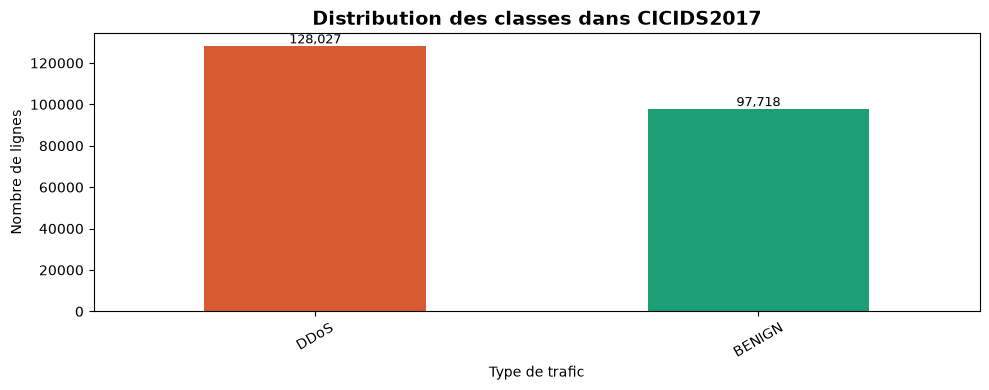


💾 Graphique sauvegardé dans data/processed/


In [ ]:

label_col = 'label'  # adapte si le nom est différent dans ton fichier

print('🏷️  Distribution des classes :')
label_counts = df[label_col].value_counts()
print(label_counts)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#1D9E75' if 'BENIGN' in str(l) else '#D85A30' for l in label_counts.index]
label_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='none')
ax.set_title('Distribution des classes dans CICIDS2017', fontsize=14, fontweight='bold')
ax.set_xlabel('Type de trafic')
ax.set_ylabel('Nombre de lignes')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('data/processed/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾 Graphique sauvegardé dans data/processed/')

In [ ]:
print('=== NETTOYAGE DES DONNÉES ===')
print(f'Avant nettoyage : {df.shape[0]:,} lignes, {df.shape[1]} colonnes\n')

# 1. Supprimer les doublons
n_before = len(df)
df = df.drop_duplicates()
print(f'✅ Doublons supprimés    : {n_before - len(df):,} lignes')

# 2. Remplacer Inf et -Inf par NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
n_nan = df.isnull().sum().sum()
print(f'✅ Valeurs Inf trouvées  : {n_nan:,} (converties en NaN)')

# 3. Supprimer les lignes avec NaN
n_before = len(df)
df.dropna(inplace=True)
print(f'✅ Lignes NaN supprimées : {n_before - len(df):,}')

# 4. Supprimer les colonnes constantes
const_cols = [c for c in df.columns if df[c].nunique() <= 1]
df.drop(columns=const_cols, inplace=True)
print(f'✅ Colonnes constantes   : {len(const_cols)} supprimées {const_cols}')

print(f'\nAprès nettoyage  : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')

=== NETTOYAGE DES DONNÉES ===
Avant nettoyage : 225,745 lignes, 79 colonnes

✅ Doublons supprimés    : 2,633 lignes
✅ Valeurs Inf trouvées  : 60 (converties en NaN)
✅ Lignes NaN supprimées : 30
✅ Colonnes constantes   : 10 supprimées ['bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'cwe_flag_count', 'fwd_avg_bytes/bulk', 'fwd_avg_packets/bulk', 'fwd_avg_bulk_rate', 'bwd_avg_bytes/bulk', 'bwd_avg_packets/bulk', 'bwd_avg_bulk_rate']

Après nettoyage  : 223,082 lignes, 69 colonnes


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0].head(20)

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing.plot(kind='bar', ax=ax, color='#D85A30')
    ax.set_title('Valeurs manquantes restantes par colonne')
    plt.tight_layout()
    plt.show()
else:
    print('✅ Aucune valeur manquante restante — données propres !')

✅ Aucune valeur manquante restante — données propres !


In [ ]:
print('[+] Création de nouvelles features...')
features_added = []

# Feature 1 : ratio paquets forward / backward
if 'total_fwd_packets' in df.columns and 'total_backward_packets' in df.columns:
    df['fwd_bwd_ratio'] = df['total_fwd_packets'] / (df['total_backward_packets'] + 1e-9)
    features_added.append('fwd_bwd_ratio')

# Feature 2 : bytes par paquet forward
if 'total_length_of_fwd_packets' in df.columns and 'total_fwd_packets' in df.columns:
    df['bytes_per_fwd_pkt'] = df['total_length_of_fwd_packets'] / (df['total_fwd_packets'] + 1e-9)
    features_added.append('bytes_per_fwd_pkt')

# Feature 3 : bucket de durée (court=0, moyen=1, long=2)
if 'flow_duration' in df.columns:
    df['duration_bucket'] = pd.cut(
        df['flow_duration'],
        bins=[-1, 1000, 100000, np.inf],
        labels=[0, 1, 2]
    ).fillna(0).astype(int)
    features_added.append('duration_bucket')

print(f'✅ Features ajoutées : {features_added}')
print(f'   Colonnes totales  : {df.shape[1]}')
df[features_added].describe().round(3)

[+] Création de nouvelles features...
✅ Features ajoutées : ['fwd_bwd_ratio', 'bytes_per_fwd_pkt', 'duration_bucket']
   Colonnes totales  : 72


,fwd_bwd_ratio,bytes_per_fwd_pkt,duration_bucket
count,2.230820e+05,223082.000,223082.000
mean,1.069669e+09,166.481,1.627
std,2.858118e+09,507.656,0.674
min,1.430000e-01,0.000,0.000
25%,6.000000e-01,6.000,1.000
50%,1.000000e+00,8.667,2.000
75%,4.000000e+00,32.000,2.000
max,2.450000e+11,3867.000,2.000


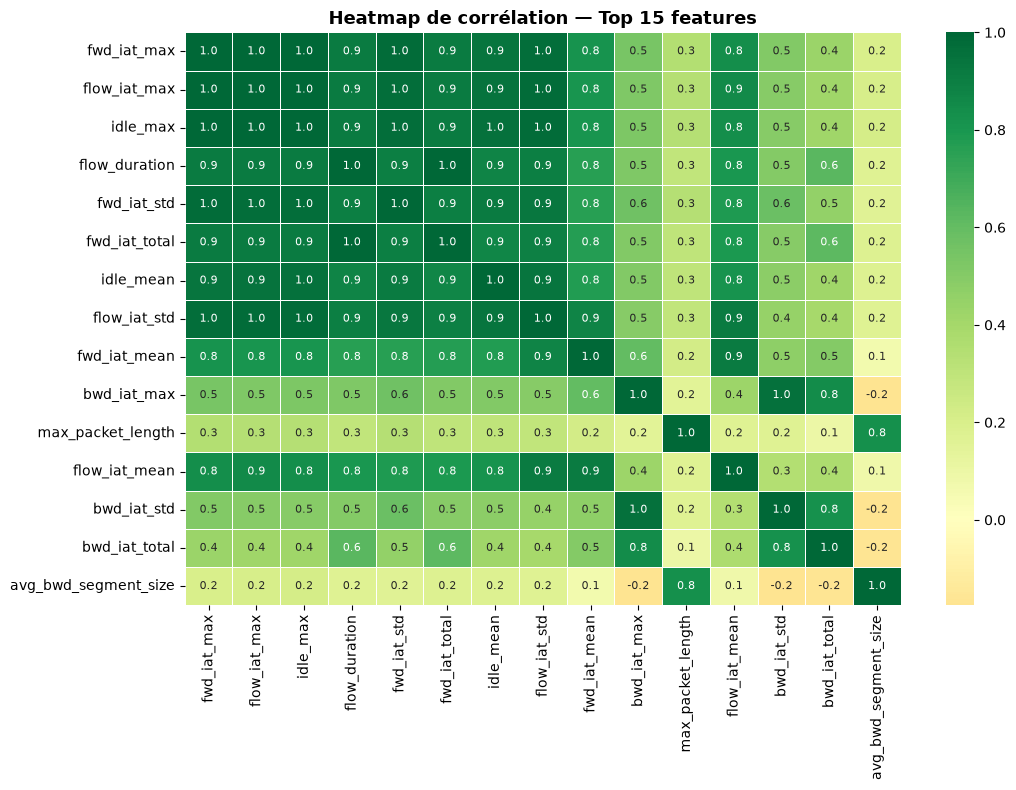

In [ ]:
import seaborn as sns
# Heatmap de corrélation des top 15 features numériques
numeric_df = df.select_dtypes(include=[np.number])
top_features = numeric_df.corr().abs().sum().sort_values(ascending=False).head(15).index

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    numeric_df[top_features].corr(),
    annot=True, fmt='.1f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Heatmap de corrélation — Top 15 features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('[+] Encodage des labels...')


le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[label_col])
print(f'   Classes trouvées : {list(le.classes_)}')

benign_id = le.transform(['BENIGN'])[0]
df['binary_label'] = (df['label_encoded'] != benign_id).astype(int)

dist = df['binary_label'].value_counts()
total = len(df)
print(f'\n📊 Distribution binaire :')
print(f'   Normal  (0) : {dist[0]:>8,}  ({dist[0]/total*100:.1f}%)')
print(f'   Attaque (1) : {dist[1]:>8,}  ({dist[1]/total*100:.1f}%)')
print(f'   Ratio déséquilibre : {dist[0]/dist[1]:.1f}x plus de normal que d\'attaques')

joblib.dump(le, 'models/label_encoder.pkl')
print('\n💾 LabelEncoder sauvegardé dans models/')

[+] Encodage des labels...
   Classes trouvées : ['BENIGN', 'DDoS']

📊 Distribution binaire :
   Normal  (0) :   95,068  (42.6%)
   Attaque (1) :  128,014  (57.4%)
   Ratio déséquilibre : 0.7x plus de normal que d'attaques

💾 LabelEncoder sauvegardé dans models/


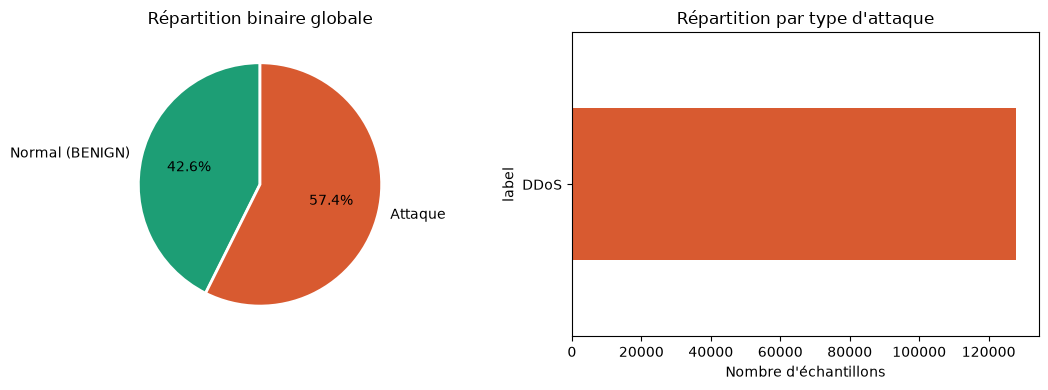

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.pie(
    [dist[0], dist[1]],
    labels=['Normal (BENIGN)', 'Attaque'],
    colors=['#1D9E75', '#D85A30'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax1.set_title('Répartition binaire globale')

attack_counts = df[df['binary_label']==1][label_col].value_counts()
attack_counts.plot(kind='barh', ax=ax2, color='#D85A30', edgecolor='none')
ax2.set_title('Répartition par type d\'attaque')
ax2.set_xlabel('Nombre d\'échantillons')

plt.tight_layout()
plt.savefig('data/processed/binary_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('[+] Sélection des features numériques...')

drop_cols = ['binary_label', 'label_encoded', label_col,
             'flow_id', 'source_ip', 'destination_ip',
             'src_ip', 'dst_ip', 'timestamp']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
y = df['binary_label']

print(f'   Features sélectionnées : {X.shape[1]}')
print(f'   Exemples totaux        : {X.shape[0]:,}')
print(f'   Noms des features      : {list(X.columns[:10])} ...')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n📊 Tailles des splits :')
print(f'   Train : {X_train.shape[0]:>7,} lignes  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test  : {X_test.shape[0]:>7,} lignes  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\n   Ratio attaques train : {y_train.mean()*100:.1f}%')
print(f'   Ratio attaques test  : {y_test.mean()*100:.1f}%  ← doit être ~identique (stratification)')

[+] Sélection des features numériques...
   Features sélectionnées : 71
   Exemples totaux        : 223,082
   Noms des features      : ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std'] ...

📊 Tailles des splits :
   Train : 178,465 lignes  (80%)
   Test  :  44,617 lignes  (20%)

   Ratio attaques train : 57.4%
   Ratio attaques test  : 57.4%  ← doit être ~identique (stratification)


In [ ]:
print('[+] Normalisation StandardScaler...')

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)     # pas de fit ici !

print(f'   Train — moyenne: {X_train_sc.mean():.4f}  écart-type: {X_train_sc.std():.4f}')
print(f'   Test  — moyenne: {X_test_sc.mean():.4f}  écart-type: {X_test_sc.std():.4f}')

joblib.dump(scaler, 'models/scaler.pkl')
print('\n💾 Scaler sauvegardé dans models/scaler.pkl')

[+] Normalisation StandardScaler...
   Train — moyenne: 0.0000  écart-type: 1.0000
   Test  — moyenne: 0.0026  écart-type: 1.0387

💾 Scaler sauvegardé dans models/scaler.pkl


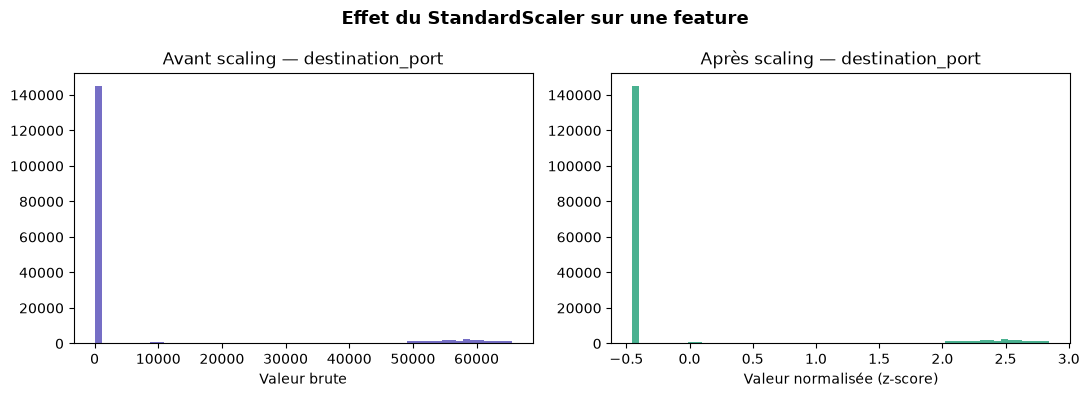

In [ ]:
feature_idx = 0
feature_name = X.columns[feature_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(X_train.iloc[:, feature_idx].clip(-1e6, 1e6), bins=60,
         color='#534AB7', alpha=0.8, edgecolor='none')
ax1.set_title(f'Avant scaling — {feature_name}')
ax1.set_xlabel('Valeur brute')

ax2.hist(X_train_sc[:, feature_idx], bins=60,
         color='#1D9E75', alpha=0.8, edgecolor='none')
ax2.set_title(f'Après scaling — {feature_name}')
ax2.set_xlabel('Valeur normalisée (z-score)')

plt.suptitle('Effet du StandardScaler sur une feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

print('[+] Application de SMOTE sur le train set...')
print(f'   Avant SMOTE — Normal: {(y_train==0).sum():,}  Attaque: {(y_train==1).sum():,}')

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)

print(f'   Après SMOTE — Normal: {(y_train_res==0).sum():,}  Attaque: {(y_train_res==1).sum():,}')
print(f'   Ratio attaques après SMOTE : {y_train_res.mean()*100:.1f}%')
print(f'   Nouvelles dimensions train : {X_train_res.shape}')

[+] Application de SMOTE sur le train set...
   Avant SMOTE — Normal: 76,054  Attaque: 102,411
   Après SMOTE — Normal: 102,411  Attaque: 102,411
   Ratio attaques après SMOTE : 50.0%
   Nouvelles dimensions train : (204822, 71)


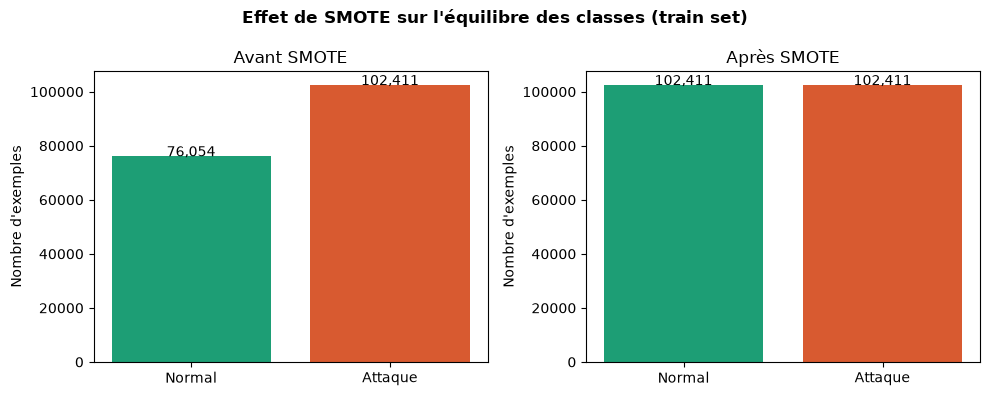

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))


counts_before = pd.Series(y_train).value_counts().sort_index()
ax1.bar(['Normal', 'Attaque'], counts_before.values,
        color=['#1D9E75', '#D85A30'], edgecolor='none')
ax1.set_title('Avant SMOTE')
ax1.set_ylabel('Nombre d\'exemples')
for i, v in enumerate(counts_before.values):
    ax1.text(i, v + 50, f'{v:,}', ha='center', fontsize=10)


counts_after = pd.Series(y_train_res).value_counts().sort_index()
ax2.bar(['Normal', 'Attaque'], counts_after.values,
        color=['#1D9E75', '#D85A30'], edgecolor='none')
ax2.set_title('Après SMOTE')
ax2.set_ylabel('Nombre d\'exemples')
for i, v in enumerate(counts_after.values):
    ax2.text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Effet de SMOTE sur l\'équilibre des classes (train set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('[+] Sauvegarde des arrays...')

np.save('data/processed/X_train.npy', X_train_res)
np.save('data/processed/X_test.npy',  X_test_sc)
np.save('data/processed/y_train.npy', y_train_res)
np.save('data/processed/y_test.npy',  y_test.values)


pd.Series(X.columns.tolist()).to_csv('data/processed/feature_names.csv', index=False)

print('✅ Fichiers sauvegardés dans data/processed/ :')
for f in os.listdir('data/processed'):
    path = f'data/processed/{f}'
    size = os.path.getsize(path) / 1024
    print(f'   {f:<35} {size:>8.1f} KB')

[+] Sauvegarde des arrays...
✅ Fichiers sauvegardés dans data/processed/ :
   binary_label_distribution.png           42.0 KB
   class_distribution.png                  32.6 KB
   correlation_heatmap.png                230.8 KB
   feature_names.csv                        1.2 KB
   scaling_effect.png                      44.5 KB
   smote_effect.png                        44.2 KB
   X_test.npy                           24748.6 KB
   X_train.npy                         113612.3 KB
   y_test.npy                             348.7 KB
   y_train.npy                           1600.3 KB


In [ ]:
print('=' * 55)
print('   RÉSUMÉ DU PREPROCESSING')
print('=' * 55)

summary = {
    'Étape'       : ['Chargement', 'Après nettoyage', 'Features engineering',
                     'Train set (avant SMOTE)', 'Train set (après SMOTE)', 'Test set'],
    'Lignes'      : [df.shape[0], df.shape[0], df.shape[0],
                     X_train_sc.shape[0], X_train_res.shape[0], X_test_sc.shape[0]],
    'Features'    : ['-', '-', X.shape[1],
                     X_train_sc.shape[1], X_train_res.shape[1], X_test_sc.shape[1]],
    '% Attaques'  : [f"{df['binary_label'].mean()*100:.1f}%",
                     f"{df['binary_label'].mean()*100:.1f}%",
                     f"{df['binary_label'].mean()*100:.1f}%",
                     f"{y_train.mean()*100:.1f}%",
                     f"{y_train_res.mean()*100:.1f}%",
                     f"{y_test.mean()*100:.1f}%"],
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print('=' * 55)
print()
print('✅ Preprocessing terminé — prêt pour le notebook 2 !')
print('   → Charger avec : X_train = np.load("data/processed/X_train.npy")')

   RÉSUMÉ DU PREPROCESSING
                  Étape  Lignes Features % Attaques
             Chargement  223082        -      57.4%
        Après nettoyage  223082        -      57.4%
   Features engineering  223082       71      57.4%
Train set (avant SMOTE)  178465       71      57.4%
Train set (après SMOTE)  204822       71      50.0%
               Test set   44617       71      57.4%

✅ Preprocessing terminé — prêt pour le notebook 2 !
   → Charger avec : X_train = np.load("data/processed/X_train.npy")
